## Name: Aryan Mahesh Patil
### Rollno: 46
#### Subject: DL
#### Experiment No: 10

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
train_data = datasets.MNIST(root='./data', train=True, download=True,
                            transform=transforms.ToTensor())
loader=DataLoader(train_data,batch_size=64,shuffle=True)

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder=nn.Linear(784,32)
        self.decoder=nn.Linear(32,784)
    def forward(self,x):
        x=x.view(-1,784)
        encoded_linear=self.encoder(x)
        encoded=torch.relu(encoded_linear)
        decoded_linear=self.decoder(encoded)
        decoded=torch.sigmoid(decoded_linear)
        return encoded, decoded

In [ ]:
model=Autoencoder()

In [ ]:
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)
for epoch in range(20):
    for images,_ in loader:
        encoded, output=model(images)
        loss=criterion(output,images.view(-1,784))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print("Epoch:",epoch+1,"Loss:",round(loss.item(),4))
    print("Encoding:",encoded)
images,labels=next(iter(loader))
with torch.no_grad():
    encoded, reconstructed=model(images)

Epoch: 1 Loss: 0.0298
Encoding: tensor([[ 6.3696, 14.4813,  0.0000,  ..., 10.4268,  0.0000,  6.9154],
        [ 7.5968,  5.2414,  0.0000,  ...,  8.8862,  0.0000,  4.8521],
        [ 5.3639, 11.0886,  0.0000,  ...,  8.8023,  0.0000,  4.0694],
        ...,
        [ 5.4451, 14.3135,  0.0000,  ..., 10.4019,  0.0000,  8.2855],
        [12.7865, 19.5631,  0.0000,  ...,  6.7160,  0.0000, 12.9780],
        [ 3.0035, 13.1490,  0.0000,  ...,  7.4576,  0.0000,  7.7562]],
       grad_fn=<ReluBackward0>)
Epoch: 2 Loss: 0.0251
Encoding: tensor([[ 8.5930,  4.5842,  0.0000,  ...,  5.2532,  0.0000,  8.8499],
        [ 3.1874,  6.7019,  0.0000,  ...,  0.2859,  0.0000,  4.7254],
        [ 9.4202, 14.0075,  0.0000,  ..., 11.5193,  0.0000,  4.5220],
        ...,
        [ 5.9067,  9.7635,  0.0000,  ...,  4.5519,  0.0000,  0.0000],
        [ 7.4901,  9.3728,  0.0000,  ...,  6.7368,  0.0000,  3.8019],
        [ 9.5788,  7.8465,  0.0000,  ...,  9.7640,  0.0000,  7.3165]],
       grad_fn=<ReluBackward0>)
Epoc

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

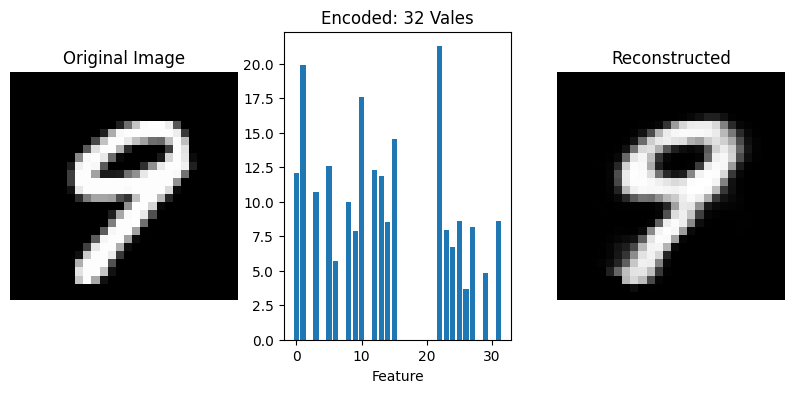

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1,3,1)
plt.imshow(images[3].squeeze(),cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,3,2)
plt.bar(range(32),encoded[3])
plt.title("Encoded: 32 Vales")
plt.xlabel("Feature")
plt.subplot(1,3,3)
plt.imshow(reconstructed[3].reshape(28,28),cmap='gray')
plt.title("Reconstructed")
plt.axis("off")